<a href="https://colab.research.google.com/github/2403a52009-bot/ML/blob/main/ml_Asn_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Boosting Classification

Dataset: sklearn Breast Cancer (built-in)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


In [ ]:
df = pd.read_csv('data.csv')   # change file name if yours is different
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.shape

(569, 33)

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
# Drop unnecessary columns if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)

# Encode target variable: M = 1, B = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


In [ ]:
depths = [3, 5, 7, 10]

results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([depth, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=['Max Depth', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_df

,Max Depth,Accuracy,Precision,Recall,F1-Score
0,3,0.903509,0.942857,0.785714,0.857143
1,5,0.921053,0.945946,0.833333,0.886076
2,7,0.938596,0.948718,0.880952,0.913580
3,10,0.929825,0.904762,0.904762,0.904762


In [ ]:
results_df

,Max Depth,Accuracy,Precision,Recall,F1-Score
0,3,0.903509,0.942857,0.785714,0.857143
1,5,0.921053,0.945946,0.833333,0.886076
2,7,0.938596,0.948718,0.880952,0.913580
3,10,0.929825,0.904762,0.904762,0.904762


In [ ]:
for depth in depths:
    print("="*60)
    print(f"Decision Tree with max_depth = {depth}")
    print("="*60)

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

Decision Tree with max_depth = 3
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        72
           1       0.94      0.79      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.91      0.90      0.90       114

Decision Tree with max_depth = 5
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114

Decision Tree with max_depth = 7
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      

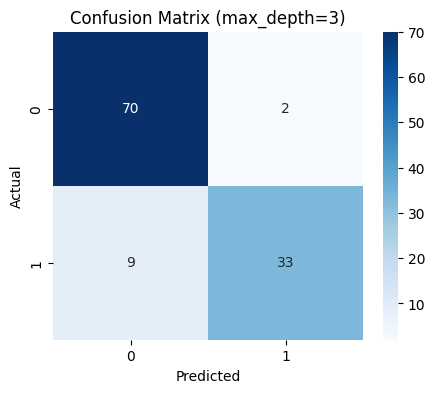

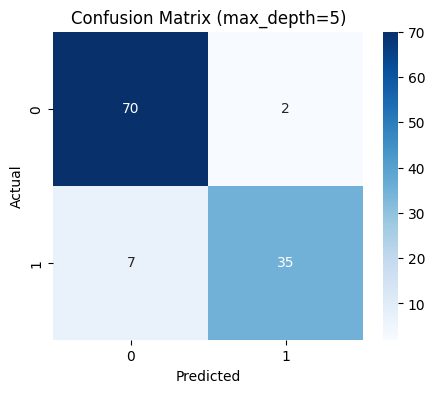

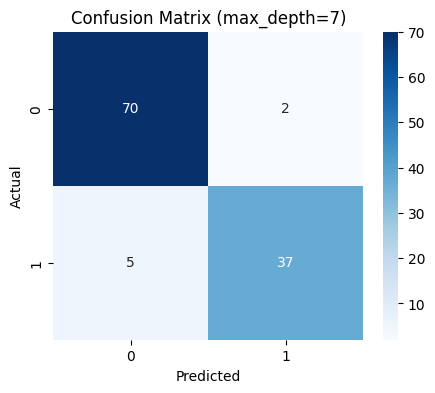

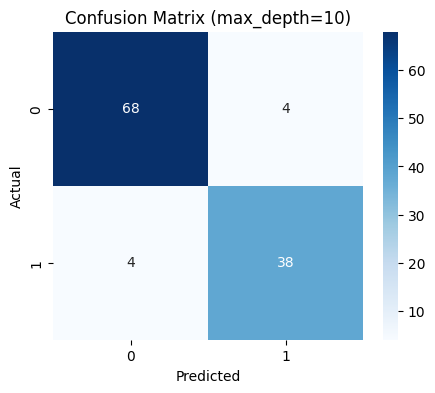

In [ ]:
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (max_depth={depth})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

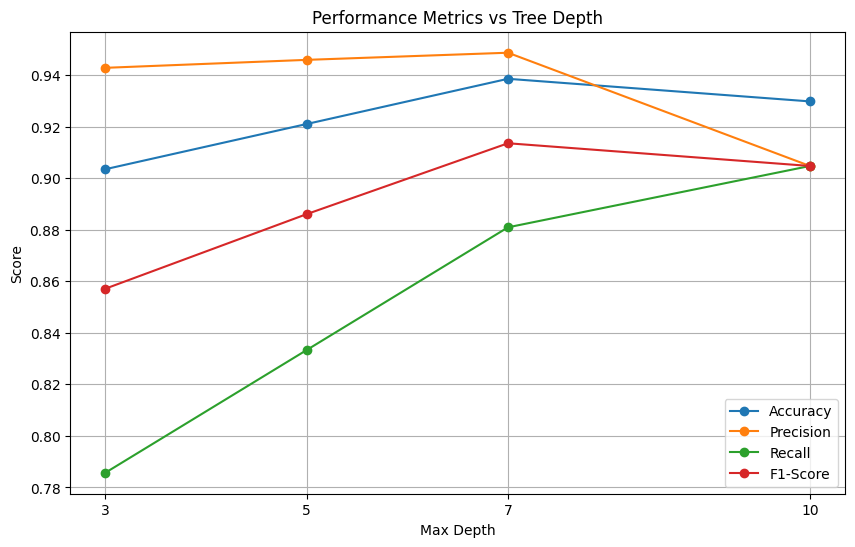

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(results_df['Max Depth'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['Max Depth'], results_df['Precision'], marker='o', label='Precision')
plt.plot(results_df['Max Depth'], results_df['Recall'], marker='o', label='Recall')
plt.plot(results_df['Max Depth'], results_df['F1-Score'], marker='o', label='F1-Score')

plt.title('Performance Metrics vs Tree Depth')
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

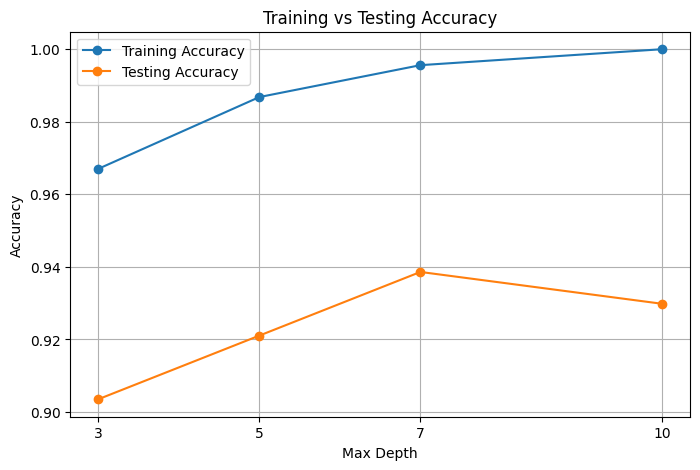

In [ ]:
train_acc = []
test_acc = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='o', label='Testing Accuracy')

plt.title('Training vs Testing Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

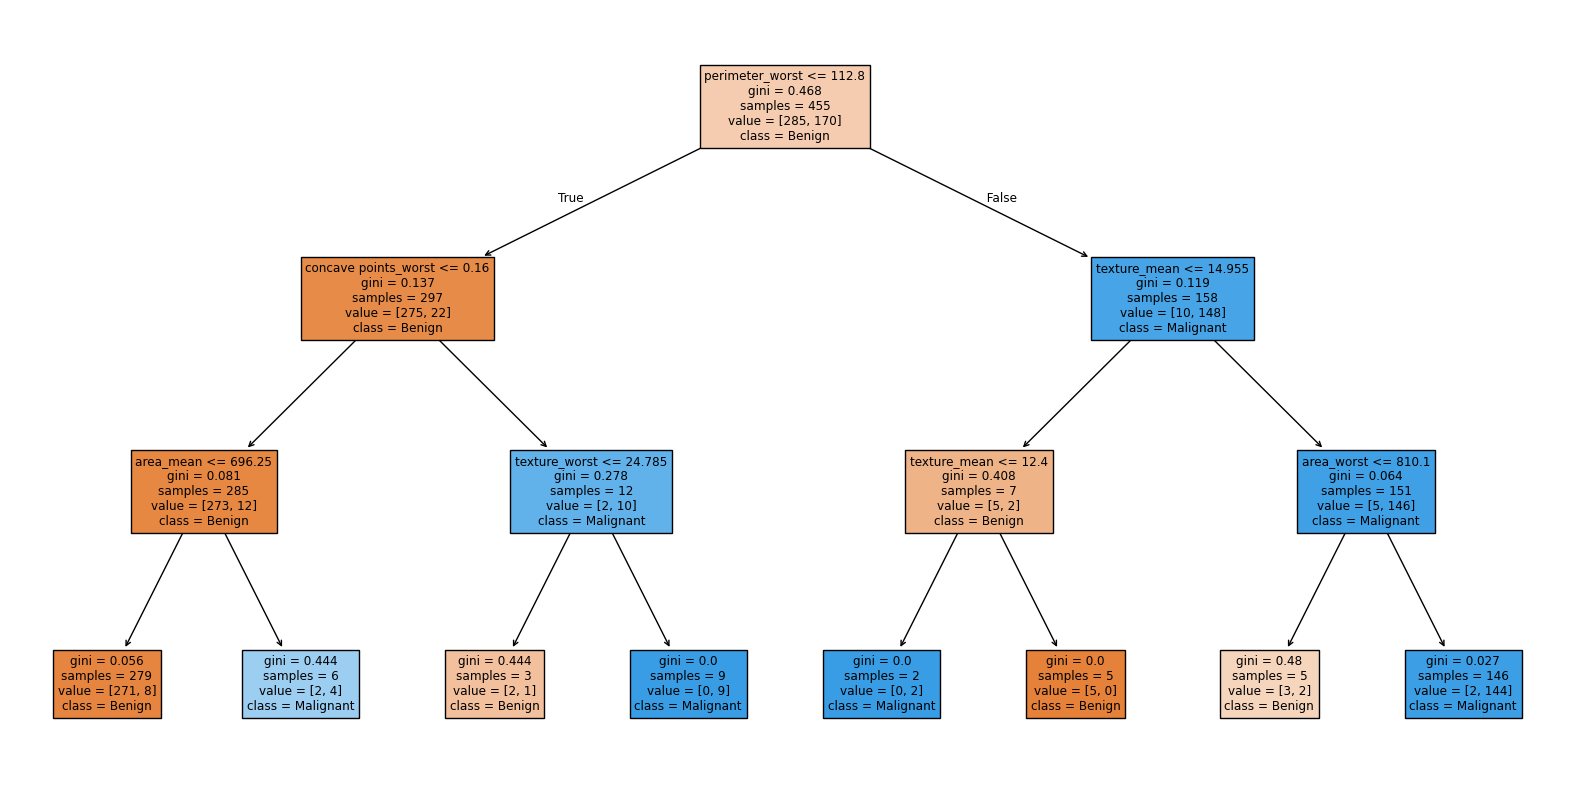

In [ ]:
best_model = DecisionTreeClassifier(max_depth=3, random_state=42)
best_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(best_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.show()

In [ ]:
print("Final Performance Comparison:\n")
print(results_df.round(4))

best_depth = results_df.loc[results_df['Accuracy'].idxmax(), 'Max Depth']
best_accuracy = results_df['Accuracy'].max()

print(f"\nBest model based on Accuracy: max_depth = {best_depth}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Final Performance Comparison:

   Max Depth  Accuracy  Precision  Recall  F1-Score
0          3    0.9035     0.9429  0.7857    0.8571
1          5    0.9211     0.9459  0.8333    0.8861
2          7    0.9386     0.9487  0.8810    0.9136
3         10    0.9298     0.9048  0.9048    0.9048

Best model based on Accuracy: max_depth = 7
Best Accuracy: 0.9386
